# Tier 1 Code Smell Classification

Train two classifiers on the CodeBERT embeddings and visualize their test-set performance.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [7]:
DATA_PATH = "https://raw.githubusercontent.com/iSMELL2024/iSMELL/main/CodeDetection/updated_dataset.xlsx"
df = pd.read_excel(DATA_PATH)
print("Loaded:", df.shape)

def parse_vec(value):
    return np.array([float(item) for item in str(value).split(",")], dtype=np.float32)

X = np.stack(df["codebert_vector"].apply(parse_vec).values)
y = df["Label"].values.astype(int)
smell = df["Smell"].to_numpy()
print("X shape:", X.shape, "y balance:", np.bincount(y))

Loaded: (654, 17)
X shape: (654, 768) y balance: [369 285]


In [8]:
strat_key = df["Smell"].astype(str) + "_" + df["Label"].astype(str)
X_train, X_test, y_train, y_test, smell_train, smell_test = train_test_split(
    X, y, smell, test_size=0.2, random_state=42, stratify=strat_key
)
print("Train:", X_train.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train: (523, 768) Test: (131, 768)


In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "MLP (128,64)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    predictions[name] = pred
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="binary", zero_division=0
    )
    results[name] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy_score(y_test, pred),
    }
    print(f"{name}: accuracy={results[name]['accuracy']:.3f}, F1={f1:.3f}")

with open(Path.cwd() / "tier1_results.json", "w") as output_file:
    json.dump(results, output_file, indent=2, default=float)

LogisticRegression: accuracy=0.740, F1=0.712
MLP (128,64): accuracy=0.740, F1=0.685


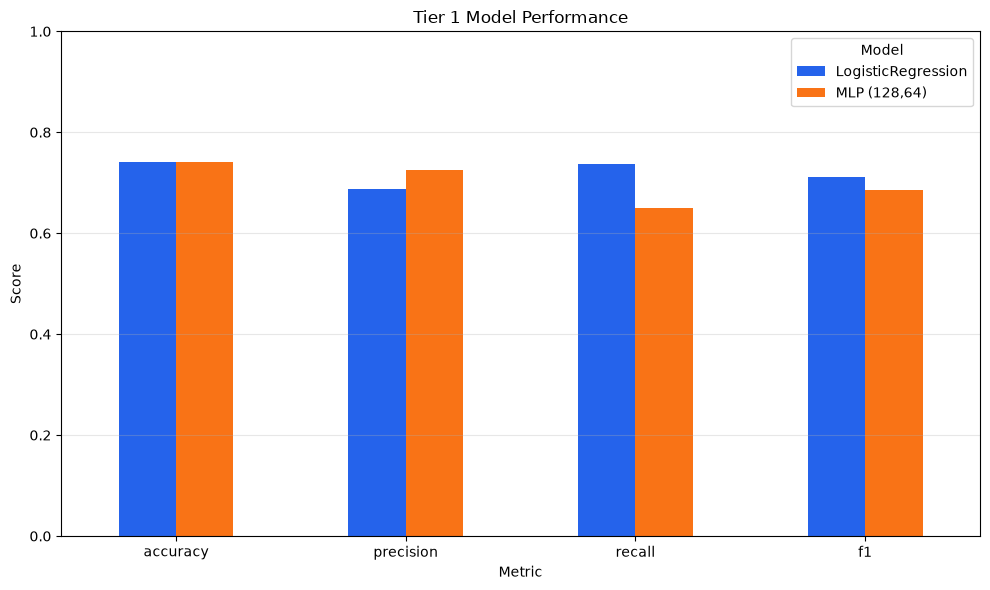

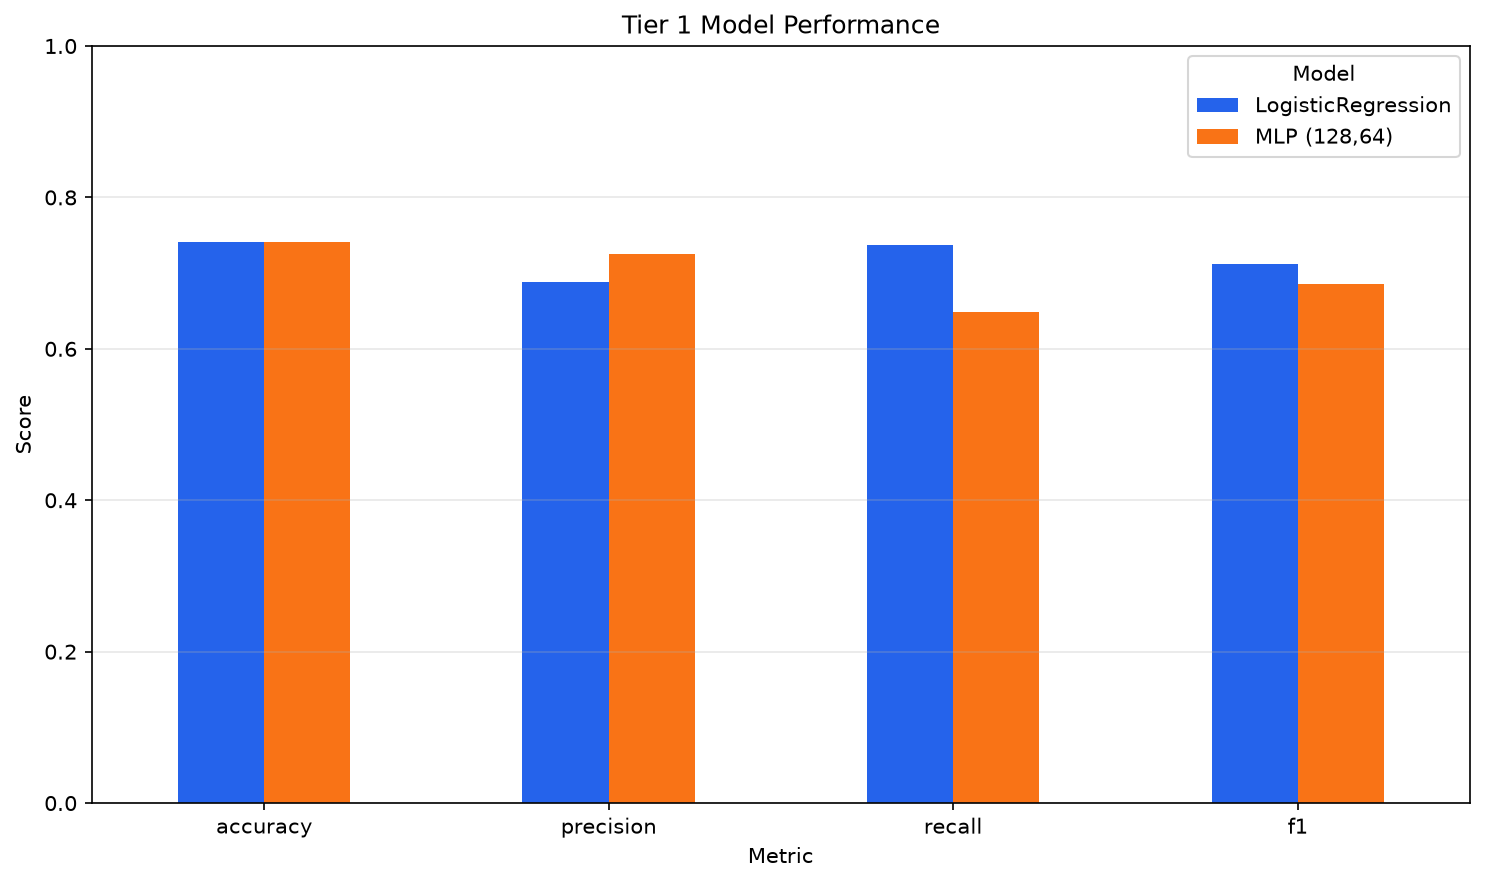

In [10]:
metrics = ["accuracy", "precision", "recall", "f1"]
performance = pd.DataFrame(results).loc[metrics]

ax = performance.plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1),
    color=["#2563eb", "#f97316"],
)
ax.set_title("Tier 1 Model Performance")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()

plot_path = Path.cwd() / "tier1_model_performance.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
display(Image(filename=str(plot_path)))